# Taiwan EV Route Planner (ABRP-style MVP)

Phases implemented:
- TDX charging + traffic ingestion
- OSM road routing (fallback: haversine)
- SOC / connector / wait / charge constraints
- Multi-stop planning (0/1/2 stops)
- Map + timeline visualizations

In [1]:
import json
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from IPython.display import HTML, display

from src.pipeline import run_pipeline_with_config, save_result
from src.viz import build_route_map

In [2]:
# User configuration
mode = "tdx"   # "sample" or "tdx"
city = "Taipei"

config = {
    "origin_lat": 25.0478,
    "origin_lon": 121.5170,
    "dest_lat": 24.1477,      # Taichung (longer trip)
    "dest_lon": 120.6736,
    "battery_kwh": 60.0,
    "soc_now_pct": 55.0,
    "reserve_soc_pct": 10.0,
    "desired_arrival_soc_pct": 15.0,
    "consumption_kwh_per_km": 0.18,
    "vehicle_connector": "CCS2",
    "avg_speed_kmh": 55.0,
    "traffic_index": 0.9,
    "charge_efficiency": 0.9,
    "min_drive_before_charge_km": 25.0,
    "max_stops": 2,
    "use_osm": False,         # set True after installing osmnx
    # For long trips in tdx mode, optionally widen coverage:
    # "cities": ["Taipei", "Taoyuan", "Hsinchu", "Taichung"],
}

In [3]:
result = run_pipeline_with_config(mode=mode, city=city, config=config)
save_result(result)
map_path = build_route_map(result)

print(f"Data source: {result['meta']['data_source']}")
print(f"Routing backend: {result.get('routing_backend')}")
print(f"Map: {map_path}")
print(json.dumps(result['route_plan'], indent=2, ensure_ascii=False)[:2500])

Data source: TDX + OSM
Routing backend: haversine
Map: outputs/route_map.html
{
  "total_time_minutes_est": 225.4,
  "final_soc_pct_est": 15.0,
  "stops": [
    {
      "station_id": "33029464-S0303",
      "name": "湖口服務區南站",
      "lat": 24.85738,
      "lon": 121.00878,
      "city": "Taipei",
      "address": "",
      "max_power_kw": 200.0,
      "connector_count": 1,
      "connector_types": [
        "CCS2"
      ]
    }
  ],
  "legs": [
    {
      "from": "origin",
      "to": "33029464-S0303",
      "distance_km_est": 70.96,
      "drive_minutes_est": 86.01,
      "polyline": [
        [
          121.517,
          25.0478
        ],
        [
          121.47464833333333,
          25.031931666666665
        ],
        [
          121.43229666666666,
          25.01606333333333
        ],
        [
          121.389945,
          25.000194999999998
        ],
        [
          121.34759333333334,
          24.984326666666664
        ],
        [
          121.3052416666666

In [4]:
route = result.get("route_plan", {})
print("Total time (min):", route.get("total_time_minutes_est"))
print("Final SOC (%):", route.get("final_soc_pct_est"))
print("Stops:", [s.get("name") for s in route.get("stops", [])])

Total time (min): 225.4
Final SOC (%): 15.0
Stops: ['湖口服務區南站']


In [5]:
display(HTML(f'<iframe src="../outputs/route_map.html" width="100%" height="520"></iframe>'))

/Users/szu-yunko/anaconda3/lib/python3.11/site-packages/IPython/core/display.py:475: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


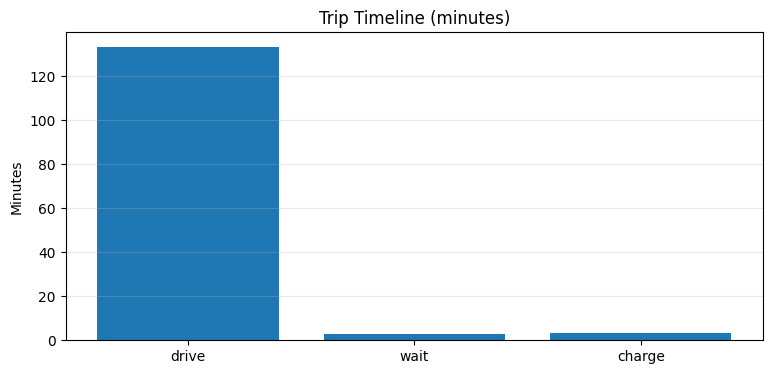

In [6]:
# SOC timeline from route legs
points = []
t = 0.0
for item in route.get("timeline", []):
    points.append((t, item.get("phase"), item.get("label")))
    t += float(item.get("duration_min", 0))

phases = route.get("timeline", [])
labels = [p.get("phase", "") for p in phases]
values = [float(p.get("duration_min", 0)) for p in phases]

plt.figure(figsize=(9, 4))
plt.bar(labels, values)
plt.title("Trip Timeline (minutes)")
plt.ylabel("Minutes")
plt.grid(axis="y", alpha=0.3)
plt.show()

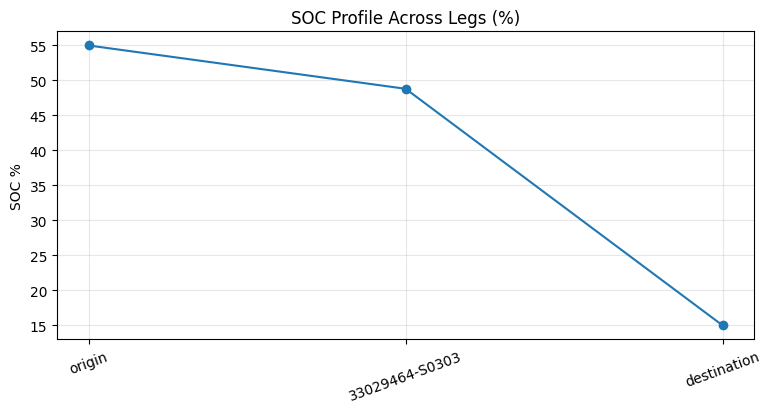

In [7]:
# SOC profile across drive legs
soc_x, soc_y = [], []
for leg in route.get("legs", []):
    soc_x.append(leg.get("from"))
    soc_y.append(leg.get("soc_start_pct"))
soc_x.append(route.get("legs", [{}])[-1].get("to", "destination"))
soc_y.append(route.get("legs", [{}])[-1].get("soc_end_pct"))

plt.figure(figsize=(9, 4))
plt.plot(range(len(soc_y)), soc_y, marker="o")
plt.xticks(range(len(soc_x)), soc_x, rotation=20)
plt.title("SOC Profile Across Legs (%)")
plt.ylabel("SOC %")
plt.grid(True, alpha=0.3)
plt.show()